In [1]:
from idlelib.search import find_again

import pandas as pd
import numpy as np

In [2]:
music_df = pd.read_csv('../../01_data/raw/train.csv')
census_df = pd.read_csv('../../01_data/raw/acs2017_census_tract_data.csv')

In [3]:
# customer_id 삭제
if 'customer_id' in music_df.columns:
    music_df = music_df.drop('customer_id', axis=1)

In [4]:
# Census 데이터 전처리
# 결측치 처리: State별 Income의 중앙값(median)으로 채우기
census_df['Income'] = census_df.groupby('State')['Income'].transform(lambda x: x.fillna(x.median()))

# 소득을 총인구로 나누어 인구당 소득 지표 생성
census_df['Income_per_Pop'] = census_df['Income'] / census_df['TotalPop'].replace(0, np.nan)

# State별로 평균값 도출
state_stats = census_df.groupby('State').agg({
    'TotalPop': 'sum',
    'Income_per_Pop': 'mean'
}).reset_index()

# 컬럼명 변경
state_stats.columns = ['State', 'State_TotalPop', 'State_AvgIncome']

In [5]:
# 데이터 병합
# location와 State 병합
final_df = pd.merge(music_df, state_stats, left_on='location', right_on='State', how='left')
final_df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,...,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State,State_TotalPop,State_AvgIncome
0,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,105.394516,...,109,18,32,52,35,46,0,Montana,1029862.0,20.310287
1,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,52.501115,...,163,44,33,12,25,37,1,New Jersey,8960161.0,29.222666
2,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,24.703696,...,117,20,129,50,28,38,0,Washington,7169967.0,16.440805
3,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,83.595480,...,252,47,120,55,17,24,0,California,38982847.0,27.057139
4,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,52.578266,...,230,41,66,40,32,47,0,Washington,7169967.0,16.440805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,-1895,29.161399,7.176704,...,22,18,199,71,41,41,0,California,38982847.0,27.057139
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,-2778,44.744198,105.069363,...,16,48,185,67,23,30,0,Maine,1330158.0,16.533594
124997,45,Maine,Family,Monthly,0,Paypal,Medium,-604,15.200073,78.064000,...,206,48,40,78,40,28,0,Maine,1330158.0,16.533594
124998,69,Maine,Free,Monthly,4,Paypal,High,-2570,35.270053,20.921062,...,108,15,41,3,35,9,1,Maine,1330158.0,16.533594


In [6]:
# 중복된 State 삭제
final_df = final_df.drop('State', axis=1)
final_df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,...,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_TotalPop,State_AvgIncome
0,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,105.394516,...,169,109,18,32,52,35,46,0,1029862.0,20.310287
1,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,52.501115,...,55,163,44,33,12,25,37,1,8960161.0,29.222666
2,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,24.703696,...,244,117,20,129,50,28,38,0,7169967.0,16.440805
3,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,83.595480,...,442,252,47,120,55,17,24,0,38982847.0,27.057139
4,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,52.578266,...,243,230,41,66,40,32,47,0,7169967.0,16.440805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,-1895,29.161399,7.176704,...,460,22,18,199,71,41,41,0,38982847.0,27.057139
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,-2778,44.744198,105.069363,...,315,16,48,185,67,23,30,0,1330158.0,16.533594
124997,45,Maine,Family,Monthly,0,Paypal,Medium,-604,15.200073,78.064000,...,11,206,48,40,78,40,28,0,1330158.0,16.533594
124998,69,Maine,Free,Monthly,4,Paypal,High,-2570,35.270053,20.921062,...,451,108,15,41,3,35,9,1,1330158.0,16.533594


In [7]:
# 추가 전처리
# 가입일 절대값 변환 (음수를 가입 기간/일수로 해석)
final_df['signup_date'] = final_df['signup_date'].abs()

In [8]:
# 데이터 정리
final_df = final_df.drop('State', axis=1, errors='ignore')
final_df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,...,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_TotalPop,State_AvgIncome
0,32,Montana,Free,Yearly,2,Paypal,Medium,1606,22.391362,105.394516,...,169,109,18,32,52,35,46,0,1029862.0,20.310287
1,64,New Jersey,Free,Monthly,3,Paypal,Low,2897,29.294210,52.501115,...,55,163,44,33,12,25,37,1,8960161.0,29.222666
2,51,Washington,Premium,Yearly,2,Credit Card,High,348,15.400312,24.703696,...,244,117,20,129,50,28,38,0,7169967.0,16.440805
3,63,California,Family,Yearly,4,Apple Pay,Medium,2894,22.842084,83.595480,...,442,252,47,120,55,17,24,0,38982847.0,27.057139
4,54,Washington,Family,Monthly,3,Paypal,High,92,23.151163,52.578266,...,243,230,41,66,40,32,47,0,7169967.0,16.440805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,1895,29.161399,7.176704,...,460,22,18,199,71,41,41,0,38982847.0,27.057139
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,2778,44.744198,105.069363,...,315,16,48,185,67,23,30,0,1330158.0,16.533594
124997,45,Maine,Family,Monthly,0,Paypal,Medium,604,15.200073,78.064000,...,11,206,48,40,78,40,28,0,1330158.0,16.533594
124998,69,Maine,Free,Monthly,4,Paypal,High,2570,35.270053,20.921062,...,451,108,15,41,3,35,9,1,1330158.0,16.533594


In [9]:
# 평균 세션 시간 단위 분 단위로 변환
final_df['average_session_length'] = final_df['average_session_length'] / 60

In [10]:
# 수치 데이터 보정
final_df['average_session_length'] = final_df['average_session_length'] / 60
final_df['weekly_unique_songs'] = np.where(
    final_df['weekly_unique_songs'] > final_df['weekly_songs_played'],
    final_df['weekly_songs_played'],
    final_df['weekly_unique_songs']
)
final_df['signup_date'] = final_df['signup_date'].abs()
final_df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,...,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_TotalPop,State_AvgIncome
0,32,Montana,Free,Yearly,2,Paypal,Medium,1606,22.391362,0.029276,...,169,109,18,32,52,35,46,0,1029862.0,20.310287
1,64,New Jersey,Free,Monthly,3,Paypal,Low,2897,29.294210,0.014584,...,55,55,44,33,12,25,37,1,8960161.0,29.222666
2,51,Washington,Premium,Yearly,2,Credit Card,High,348,15.400312,0.006862,...,244,117,20,129,50,28,38,0,7169967.0,16.440805
3,63,California,Family,Yearly,4,Apple Pay,Medium,2894,22.842084,0.023221,...,442,252,47,120,55,17,24,0,38982847.0,27.057139
4,54,Washington,Family,Monthly,3,Paypal,High,92,23.151163,0.014605,...,243,230,41,66,40,32,47,0,7169967.0,16.440805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,1895,29.161399,0.001994,...,460,22,18,199,71,41,41,0,38982847.0,27.057139
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,2778,44.744198,0.029186,...,315,16,48,185,67,23,30,0,1330158.0,16.533594
124997,45,Maine,Family,Monthly,0,Paypal,Medium,604,15.200073,0.021684,...,11,11,48,40,78,40,28,0,1330158.0,16.533594
124998,69,Maine,Free,Monthly,4,Paypal,High,2570,35.270053,0.005811,...,451,108,15,41,3,35,9,1,1330158.0,16.533594


In [11]:
# 문자열 처리
final_df = final_df.drop('State_TotalPop', axis=1, errors='ignore')
final_df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome
0,32,Montana,Free,Yearly,2,Paypal,Medium,1606,22.391362,0.029276,0.176873,169,109,18,32,52,35,46,0,20.310287
1,64,New Jersey,Free,Monthly,3,Paypal,Low,2897,29.294210,0.014584,0.981811,55,55,44,33,12,25,37,1,29.222666
2,51,Washington,Premium,Yearly,2,Credit Card,High,348,15.400312,0.006862,0.048411,244,117,20,129,50,28,38,0,16.440805
3,63,California,Family,Yearly,4,Apple Pay,Medium,2894,22.842084,0.023221,0.035691,442,252,47,120,55,17,24,0,27.057139
4,54,Washington,Family,Monthly,3,Paypal,High,92,23.151163,0.014605,0.039738,243,230,41,66,40,32,47,0,16.440805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,1895,29.161399,0.001994,0.893839,460,22,18,199,71,41,41,0,27.057139
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,2778,44.744198,0.029186,0.668759,315,16,48,185,67,23,30,0,16.533594
124997,45,Maine,Family,Monthly,0,Paypal,Medium,604,15.200073,0.021684,0.286604,11,11,48,40,78,40,28,0,16.533594
124998,69,Maine,Free,Monthly,4,Paypal,High,2570,35.270053,0.005811,0.092528,451,108,15,41,3,35,9,1,16.533594


In [12]:
# 결과 확인
print(f"최종 데이터 형태: {final_df.shape}")
display(final_df.head())

최종 데이터 형태: (125000, 20)


,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome
0,32,Montana,Free,Yearly,2,Paypal,Medium,1606,22.391362,0.029276,0.176873,169,109,18,32,52,35,46,0,20.310287
1,64,New Jersey,Free,Monthly,3,Paypal,Low,2897,29.294210,0.014584,0.981811,55,55,44,33,12,25,37,1,29.222666
2,51,Washington,Premium,Yearly,2,Credit Card,High,348,15.400312,0.006862,0.048411,244,117,20,129,50,28,38,0,16.440805
3,63,California,Family,Yearly,4,Apple Pay,Medium,2894,22.842084,0.023221,0.035691,442,252,47,120,55,17,24,0,27.057139
4,54,Washington,Family,Monthly,3,Paypal,High,92,23.151163,0.014605,0.039738,243,230,41,66,40,32,47,0,16.440805


# EDA 진행
- 기본 (수아님)
- 거주하는 주의 인당소득이 높을수록 이탈률이 낮을 것이다
- 하나 더(본인 아이디어)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
final_df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome
0,32,Montana,Free,Yearly,2,Paypal,Medium,1606,22.391362,0.029276,0.176873,169,109,18,32,52,35,46,0,20.310287
1,64,New Jersey,Free,Monthly,3,Paypal,Low,2897,29.294210,0.014584,0.981811,55,55,44,33,12,25,37,1,29.222666
2,51,Washington,Premium,Yearly,2,Credit Card,High,348,15.400312,0.006862,0.048411,244,117,20,129,50,28,38,0,16.440805
3,63,California,Family,Yearly,4,Apple Pay,Medium,2894,22.842084,0.023221,0.035691,442,252,47,120,55,17,24,0,27.057139
4,54,Washington,Family,Monthly,3,Paypal,High,92,23.151163,0.014605,0.039738,243,230,41,66,40,32,47,0,16.440805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,1895,29.161399,0.001994,0.893839,460,22,18,199,71,41,41,0,27.057139
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,2778,44.744198,0.029186,0.668759,315,16,48,185,67,23,30,0,16.533594
124997,45,Maine,Family,Monthly,0,Paypal,Medium,604,15.200073,0.021684,0.286604,11,11,48,40,78,40,28,0,16.533594
124998,69,Maine,Free,Monthly,4,Paypal,High,2570,35.270053,0.005811,0.092528,451,108,15,41,3,35,9,1,16.533594


In [15]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         125000 non-null  int64  
 1   location                    125000 non-null  str    
 2   subscription_type           125000 non-null  str    
 3   payment_plan                125000 non-null  str    
 4   num_subscription_pauses     125000 non-null  int64  
 5   payment_method              125000 non-null  str    
 6   customer_service_inquiries  125000 non-null  str    
 7   signup_date                 125000 non-null  int64  
 8   weekly_hours                125000 non-null  float64
 9   average_session_length      125000 non-null  float64
 10  song_skip_rate              125000 non-null  float64
 11  weekly_songs_played         125000 non-null  int64  
 12  weekly_unique_songs         125000 non-null  int64  
 13  num_favorite_artists     

### 1. 거주하는 주의 인당소득이 높을수록 이탈률이 낮을 것이다

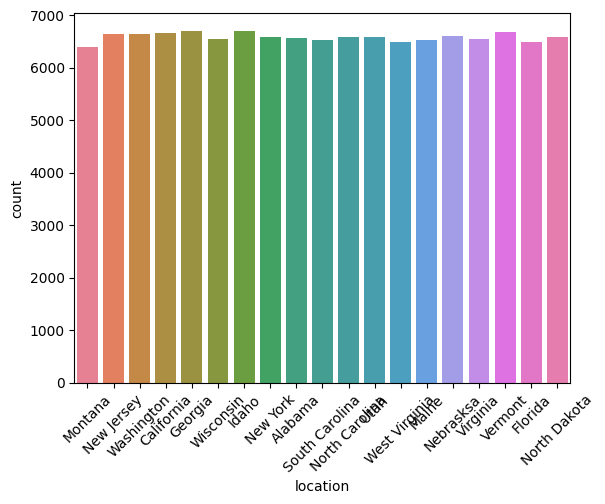

In [19]:
sns.countplot(data=final_df, x='location', hue='location')
plt.xticks(rotation=45)
plt.show()

In [17]:
# 각 주 당 인구 수
location_group = final_df.groupby('location').size()

In [18]:
# 총 19개의 주
final_df['location'].nunique()

19

In [40]:
location_group = final_df.groupby('location')['State_AvgIncome'].mean()
location_group

location
Alabama           17.944016
California        27.057139
Florida           18.512066
Georgia           12.810438
Idaho             17.239318
Maine             16.533594
Montana           20.310287
Nebrasksa               NaN
New Jersey        29.222666
New York          51.501162
North Carolina    14.114262
North Dakota      23.335164
South Carolina    14.656758
Utah              17.314439
Vermont           20.872229
Virginia          30.992474
Washington        16.440805
West Virginia     13.419987
Wisconsin         15.730921
Name: State_AvgIncome, dtype: float64

Nebrasksa 주는 state_avgincome이 전부 NaN이므로 drop 진행

In [61]:
final_df[final_df['location'] == 'Nebrasksa']

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome
32,76,Nebrasksa,Free,Monthly,0,Apple Pay,High,2818,35.262531,0.001461,0.628706,148,14,40,29,39,22,29,1,NaN
54,34,Nebrasksa,Family,Yearly,3,Debit Card,High,2393,13.696973,0.003824,0.872201,471,62,20,141,17,7,15,1,NaN
87,77,Nebrasksa,Student,Monthly,1,Apple Pay,High,1226,15.780962,0.032500,0.030729,305,150,2,54,11,40,16,1,NaN
210,79,Nebrasksa,Family,Monthly,2,Credit Card,High,951,4.327881,0.006041,0.831925,499,236,14,183,86,1,43,1,NaN
217,67,Nebrasksa,Student,Yearly,3,Apple Pay,Medium,450,19.441614,0.017946,0.046128,378,280,12,130,86,23,16,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124760,68,Nebrasksa,Free,Yearly,2,Debit Card,Low,1886,35.961244,0.018974,0.836604,384,213,8,95,53,27,30,1,NaN
124906,63,Nebrasksa,Student,Yearly,0,Apple Pay,Low,2061,23.691129,0.005643,0.003711,191,74,17,14,93,46,48,0,NaN
124923,69,Nebrasksa,Free,Monthly,4,Apple Pay,Medium,134,46.398765,0.023716,0.964447,390,75,19,21,33,11,26,1,NaN
124933,40,Nebrasksa,Free,Yearly,4,Paypal,High,251,38.290050,0.011472,0.229585,236,236,10,82,60,19,45,1,NaN


In [63]:
drop_final_df = final_df.loc[final_df['location'] != 'Nebrasksa']
location_group = final_df.groupby('location').size()
location_group

location
Alabama           6555
California        6665
Florida           6480
Georgia           6705
Idaho             6697
Maine             6523
Montana           6401
Nebrasksa         6601
New Jersey        6634
New York          6574
North Carolina    6583
North Dakota      6577
South Carolina    6534
Utah              6577
Vermont           6676
Virginia          6541
Washington        6638
West Virginia     6486
Wisconsin         6553
dtype: int64

In [64]:
drop_final_df['location'].nunique()

18

In [65]:
# 주 당 평균 소득
location_income = drop_final_df.groupby('location')['State_AvgIncome'].mean()
location_income

location
Alabama           17.944016
California        27.057139
Florida           18.512066
Georgia           12.810438
Idaho             17.239318
Maine             16.533594
Montana           20.310287
New Jersey        29.222666
New York          51.501162
North Carolina    14.114262
North Dakota      23.335164
South Carolina    14.656758
Utah              17.314439
Vermont           20.872229
Virginia          30.992474
Washington        16.440805
West Virginia     13.419987
Wisconsin         15.730921
Name: State_AvgIncome, dtype: float64

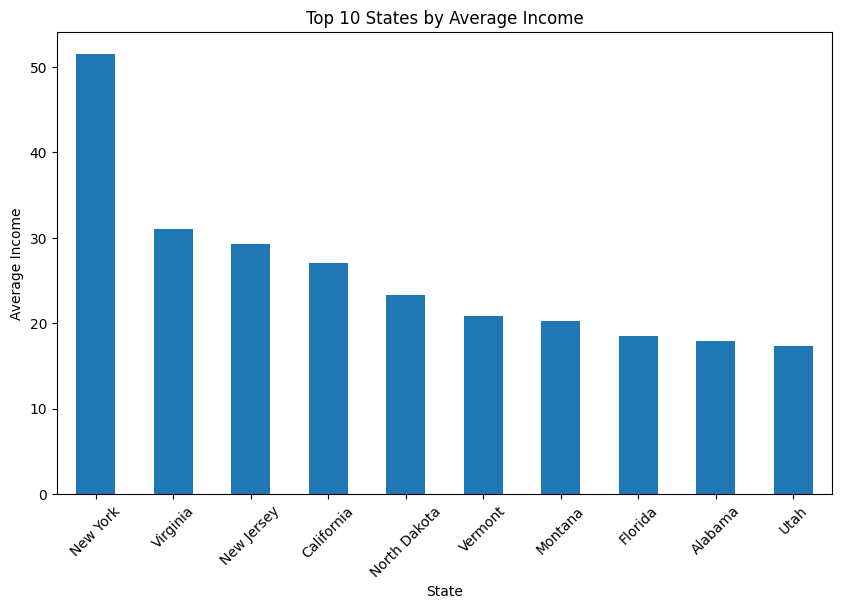

In [66]:
location_income.sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(10,6)
)

plt.xlabel('State')
plt.ylabel('Average Income')
plt.title('Top 10 States by Average Income')
plt.xticks(rotation=45)
plt.show()

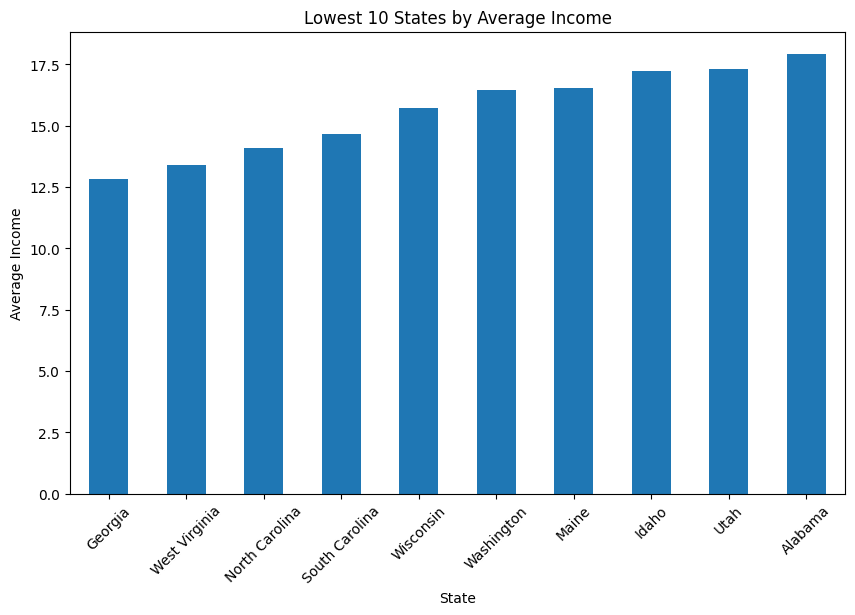

In [67]:
location_income.sort_values().head(10).plot(
    kind='bar', figsize=(10,6)
)

plt.xlabel('State')
plt.ylabel('Average Income')
plt.title('Lowest 10 States by Average Income')
plt.xticks(rotation=45)
plt.show()

In [68]:
# 주 별 이탈률
location_churn = drop_final_df.groupby('location')['churned'].mean()
location_churn

location
Alabama           0.510450
California        0.513878
Florida           0.508179
Georgia           0.521551
Idaho             0.511274
Maine             0.505289
Montana           0.512420
New Jersey        0.516883
New York          0.510648
North Carolina    0.513444
North Dakota      0.516041
South Carolina    0.516529
Utah              0.514824
Vermont           0.515578
Virginia          0.505733
Washington        0.517324
West Virginia     0.513876
Wisconsin         0.517168
Name: churned, dtype: float64

In [69]:
# 평균 소득과 같이 보기
state_analysis = drop_final_df.groupby('location').agg({
    'State_AvgIncome': 'mean',
    'churned': 'mean'
})

state_analysis.rename(columns={'churned':'ChurnRate'}, inplace=True)

state_analysis

,State_AvgIncome,ChurnRate
location,,
Alabama,17.944016,0.510450
California,27.057139,0.513878
Florida,18.512066,0.508179
Georgia,12.810438,0.521551
Idaho,17.239318,0.511274
Maine,16.533594,0.505289
Montana,20.310287,0.512420
New Jersey,29.222666,0.516883
New York,51.501162,0.510648


<Axes: title={'center': 'Churn Rate by State'}, xlabel='location'>

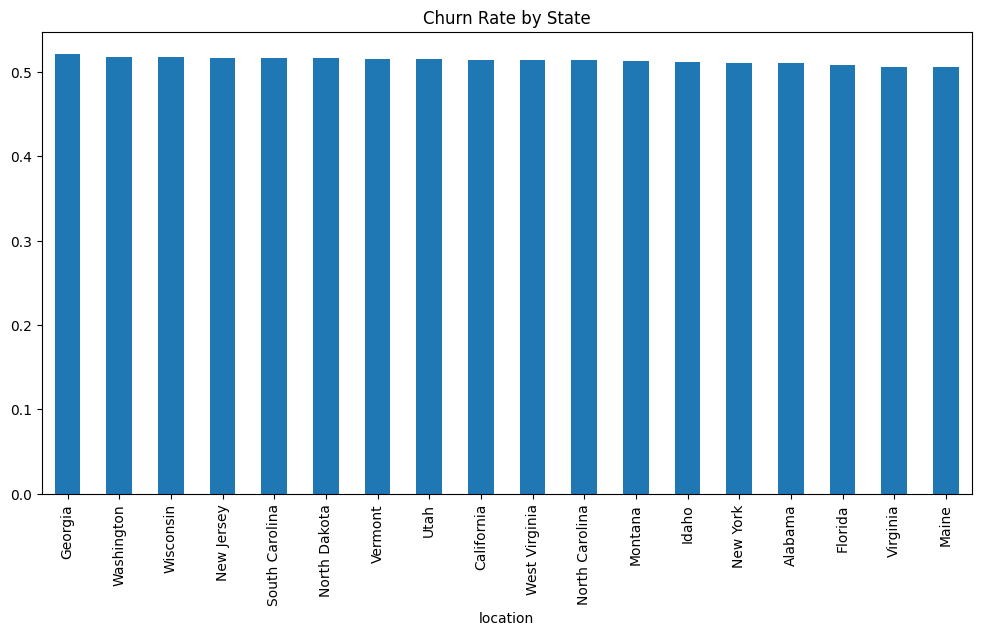

In [70]:
location_churn.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,6),
    title='Churn Rate by State'
)

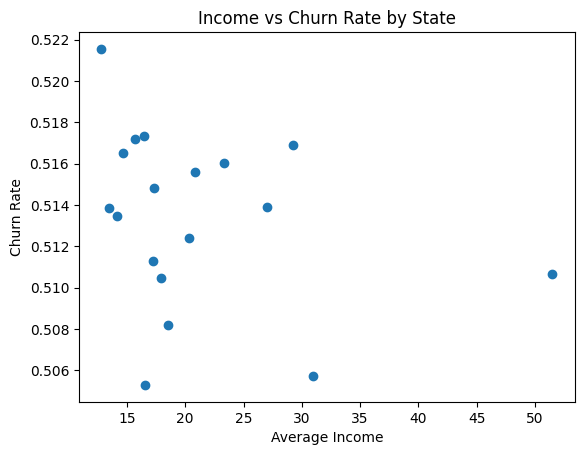

In [73]:
#소득과 이탈률
import matplotlib.pyplot as plt

plt.scatter(state_analysis['State_AvgIncome'], state_analysis['ChurnRate'])

plt.xlabel('Average Income')
plt.ylabel('Churn Rate')
plt.title('Income vs Churn Rate by State')

plt.show()

해석: 이탈률 값의 범위가 0.505 ~ 0.522 사이로 매우 좁고 선형관계를 찾기는 힘들다. 결과적으로 소득 수준이 높은 주라고 해서 고객 이탈률이 낮아지거나 높아지는 뚜렷한 경향은 발견되지 않았다.

+) 오른쪽 끝에 있는 이상치(outlier) 하나는 다른 주보다 소득이 훨씬 높은 주인데 이탈률은 특별히 낮지도 높지도 않음 -> 소득이 매우 높은 주에서도 이탈률이 크게 달라지지 않는다고 해석할 수 있음

In [74]:
# 단위가 thousand로 보고, Income과 churn의 상관관계
state_analysis[['State_AvgIncome','ChurnRate']].corr()

,State_AvgIncome,ChurnRate
State_AvgIncome,1.000000,-0.283549
ChurnRate,-0.283549,1.000000


분석: 약한 음의 상관관계 -> 소득이 높을수록 이탈률이 약간 낮아지는 경향은 있지만 크게 영향이 있지는 않다.

다만, 인당 소득이 아니라 평균 소득이기에 상관관계가 약한 것이 정상적이다.-> 하지만 데이터 자체가 인당 이탈여부와 소득이 같이 있는 게 아니라서 매칭할 수  없으므로 인당분석은 진행이 불가함

### 2. 주간 청취 시간이 적을수록 이탈률이 높을 것이다

In [90]:
drop_final_df['weekly_hours'].agg(['min','max'])

min     0.000068
max    49.999943
Name: weekly_hours, dtype: float64

In [91]:
drop_final_df['weekly_hours'].describe()

count    118399.000000
mean         25.031754
std          14.450178
min           0.000068
25%          12.466623
50%          25.099106
75%          37.567781
max          49.999943
Name: weekly_hours, dtype: float64

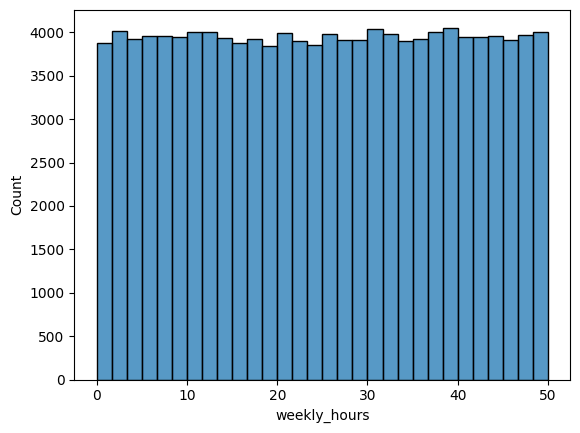

In [92]:
# 시간 변수 히스토그램으로 확인
sns.histplot(drop_final_df['weekly_hours'], bins=30)
plt.show()

In [94]:
# qcut으로 구간 나누고 이탈률 계산
eda_df = drop_final_df.copy()

eda_df['hours_group'] = pd.cut(
    eda_df['weekly_hours'],
    bins=[0,15,35,50],
    labels=['Low','Medium','High']
)

hours_churn = eda_df.groupby('hours_group')['churned'].mean()
print(hours_churn)

hours_group
Low       0.701537
Medium    0.498736
High      0.345235
Name: churned, dtype: float64


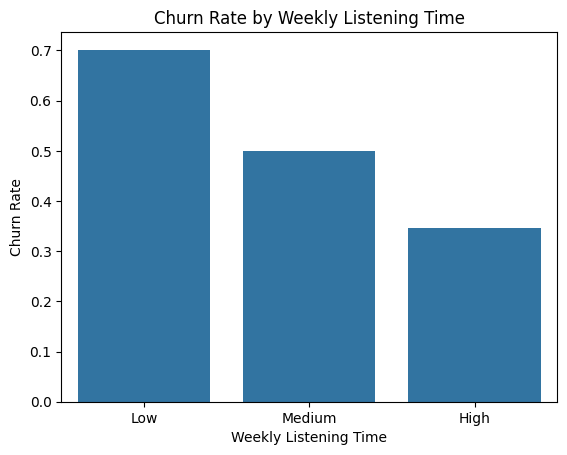

In [96]:
sns.barplot(x=hours_churn.index, y=hours_churn.values)

plt.xlabel("Weekly Listening Time")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Weekly Listening Time")

plt.show()

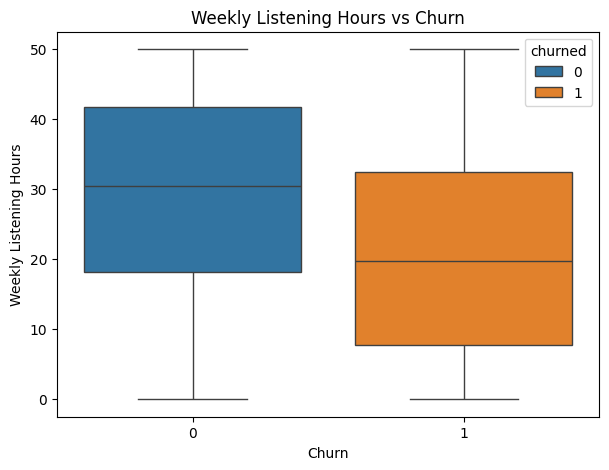

In [97]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='churned',
    y='weekly_hours',
    data=eda_df,
    hue='churned',
)

plt.xlabel("Churn")
plt.ylabel("Weekly Listening Hours")
plt.title("Weekly Listening Hours vs Churn")

plt.show()

분석: 주간 청취 시간에 따른 고객 이탈률을 분석한 결과, 청취 시간이 낮은 사용자 그룹에서 이탈률이 상대적으로 높게 나타났다. 이는 플랫폼 이용 빈도가 낮은 사용자가 서비스에 대한 의존도가 낮아 이탈할 가능성이 높음을 시사한다.

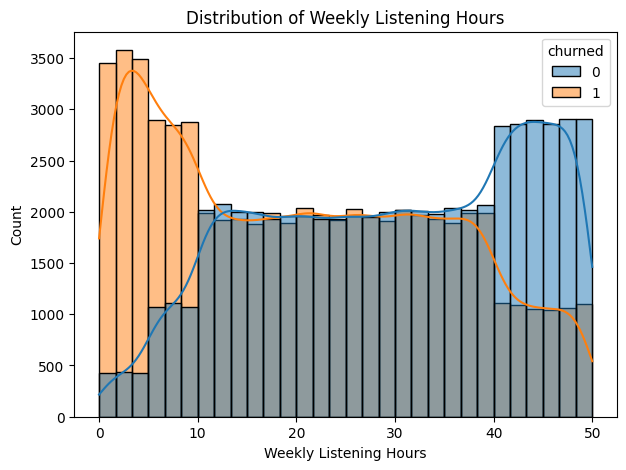

In [102]:
# 추가
# churn 사용자와 active 사용자의 사용량 분포 차이
plt.figure(figsize=(7,5))

sns.histplot(
    data=eda_df,
    x='weekly_hours',
    hue='churned',
    bins=30,
    kde=True
)

plt.xlabel('Weekly Listening Hours')
plt.title('Distribution of Weekly Listening Hours')

plt.show()